In [15]:

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
np.random.seed(42)

OUTPUT = "output"
os.makedirs(OUTPUT, exist_ok=True)

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#c8c8e8',
    'xtick.color':      '#c8c8e8',
    'ytick.color':      '#c8c8e8',
    'text.color':       '#c8c8e8',
    'grid.color':       '#2a2a4a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})
PALETTE = ["#9f92ea", "#f19ab7", "#8cdeef", "#f0e18b", "#81cb93", "#e1b578"]


In [16]:

from datetime import datetime, timedelta

N = 2000   # rows per table
rng = np.random.default_rng(42)

STATES = ['CA','TX','FL','NY','IL','OH','GA','NC','MI','WA']
INS_TYPES = ['Auto','Health','Home','Life','Travel']
EMP_STATUS = ['Employed','Self-Employed','Unemployed','Retired']
MARITAL = ['Single','Married','Divorced','Widowed']
HOUSE = ['Rented','Owned','Leased']
SOCIAL = ['Upper','Middle','Lower']
EDU = ['High School','Bachelor','Master','PhD','None']
RISK_SEG = ['Low','Medium','High']
SEVERITY = ['Minor','Moderate','Major','Severe']
AUTHORITY = ['Police','Fire','Ambulance','None']
CLAIM_STATUS = ['Approved','Rejected','Under Investigation']

def rand_date(start='2019-01-01', end='2025-12-31'):
    s = datetime.strptime(start, '%Y-%m-%d')
    e = datetime.strptime(end,   '%Y-%m-%d')
    delta = (e - s).days
    return [(s + timedelta(days=int(d))).strftime('%Y-%m-%d')
            for d in rng.integers(0, delta, N)]

agent_ids  = [f'AGT{str(i).zfill(4)}' for i in range(1, 201)]
vendor_ids = [f'VND{str(i).zfill(4)}' for i in range(1, 51)]
cust_ids   = [f'CUST{str(i).zfill(5)}' for i in range(1, N+1)]
pol_nums   = [f'POL{str(i).zfill(6)}' for i in range(1, N+1)]

# ── fraud flag (≈15% fraud) ──────────────────────────────────────────────────
fraud_prob = rng.random(N)
is_fraud   = (fraud_prob < 0.15).astype(int)

premium  = rng.integers(500,  5000, N)
# fraud claims are inflated
claim    = np.where(is_fraud,
                    rng.integers(8000, 50000, N),
                    rng.integers(200,  7000,  N))

# ─────────────────────────────────────────────────────────────────────────────
# policy_data.csv
policy_data = pd.DataFrame({
    'POLICY_NUMBER':    pol_nums,
    'CUSTOMER_ID':      cust_ids,
    'AGENT_ID':         rng.choice(agent_ids, N),
    'INSURANCE_TYPE':   rng.choice(INS_TYPES, N),
    'POLICY_EFF_DT':    rand_date('2015-01-01','2023-12-31'),
    'PREMIUM_AMOUNT':   premium,
    'RISK_SEGMENTATION':rng.choice(RISK_SEG,   N, p=[0.5,0.35,0.15]),
    'CLAIM_STATUS':     rng.choice(CLAIM_STATUS,N, p=[0.60,0.25,0.15]),
    'STATE':            rng.choice(STATES, N),
    'IS_FRAUD':         is_fraud,
})

# ─────────────────────────────────────────────────────────────────────────────
# claims_history.csv
claims_history = pd.DataFrame({
    'TRANSACTION_ID':           [f'TXN{str(i).zfill(7)}' for i in range(1,N+1)],
    'POLICY_NUMBER':            pol_nums,
    'CUSTOMER_ID':              cust_ids,
    'LOSS_DT':                  rand_date('2019-01-01','2024-06-30'),
    'REPORT_DT':                rand_date('2019-01-15','2024-07-15'),
    'CLAIM_AMOUNT':             claim,
    'PREMIUM_AMOUNT':           premium,
    'INCIDENT_SEVERITY':        rng.choice(SEVERITY, N, p=[0.3,0.35,0.25,0.10]),
    'INCIDENT_HOUR_OF_THE_DAY': rng.integers(0, 24, N),
    'AUTHORITY_CONTACTED':      rng.choice(AUTHORITY, N),
    'ANY_INJURY':               rng.choice([0,1], N, p=[0.7,0.3]),
    'POLICE_REPORT_AVAILABLE':  rng.choice([0,1], N, p=[0.45,0.55]),
    'INCIDENT_STATE':           rng.choice(STATES, N),
    'VENDOR_ID':                rng.choice(vendor_ids, N),
    'IS_FRAUD':                 is_fraud,
})

# ─────────────────────────────────────────────────────────────────────────────
# customer_profiles.csv
ages    = rng.integers(18, 80, N)
tenure  = rng.integers(1, 20, N)
customer_profiles = pd.DataFrame({
    'CUSTOMER_ID':              cust_ids,
    'CUSTOMER_NAME':            [f'Customer_{i}' for i in range(1,N+1)],
    'AGE':                      ages,
    'MARITAL_STATUS':           rng.choice(MARITAL, N),
    'EMPLOYMENT_STATUS':        rng.choice(EMP_STATUS, N),
    'NO_OF_FAMILY_MEMBERS':     rng.integers(1, 8, N),
    'HOUSE_TYPE':               rng.choice(HOUSE, N),
    'SOCIAL_CLASS':             rng.choice(SOCIAL, N, p=[0.15,0.60,0.25]),
    'CUSTOMER_EDUCATION_LEVEL': rng.choice(EDU, N),
    'TENURE':                   tenure,
    'SSN':                      [f'{rng.integers(100,999)}-{rng.integers(10,99)}-{rng.integers(1000,9999)}' for _ in range(N)],
    'STATE':                    rng.choice(STATES, N),
    'IS_FRAUD':                 is_fraud,
})

# ─────────────────────────────────────────────────────────────────────────────
# agent_performance.csv
agent_df_ids = rng.choice(agent_ids, N)
agent_performance = pd.DataFrame({
    'AGENT_ID':              agent_df_ids,
    'TOTAL_POLICIES':        rng.integers(10, 500, N),
    'FRAUD_CASES_HANDLED':   rng.integers(0, 30, N),
    'AVG_CLAIM_AMOUNT':      rng.integers(1000, 20000, N),
    'APPROVAL_RATE':         rng.uniform(0.4, 0.95, N).round(3),
    'CUSTOMER_COMPLAINTS':   rng.integers(0, 15, N),
    'YEARS_EXPERIENCE':      rng.integers(1, 25, N),
    'PERFORMANCE_SCORE':     rng.uniform(50, 100, N).round(2),
    'STATE':                 rng.choice(STATES, N),
})

# save
for name, df in [('policy_data', policy_data),
                 ('claims_history', claims_history),
                 ('customer_profiles', customer_profiles),
                 ('agent_performance', agent_performance)]:
    df.to_csv(f'input/{name}.csv', index=False)
    print(f"{name}.csv  →  {df.shape}")


policy_data.csv  →  (2000, 10)
claims_history.csv  →  (2000, 15)
customer_profiles.csv  →  (2000, 13)
agent_performance.csv  →  (2000, 9)


In [18]:
policy_data       = pd.read_csv('input/policy_data.csv')
claims_history    = pd.read_csv('input/claims_history.csv')
customer_profiles = pd.read_csv('input/customer_profiles.csv')
agent_performance = pd.read_csv('input/agent_performance.csv')

print("=== NULL SUMMARY ===")
for name, df in [('policy_data', policy_data),
                 ('claims_history', claims_history),
                 ('customer_profiles', customer_profiles),
                 ('agent_performance', agent_performance)]:
    nulls = df.isnull().sum().sum()
    print(f"  {name:25s}: {nulls} nulls")


=== NULL SUMMARY ===
  policy_data              : 0 nulls
  claims_history           : 481 nulls
  customer_profiles        : 373 nulls
  agent_performance        : 0 nulls


In [19]:
df = (claims_history
      .merge(policy_data.drop(columns=['IS_FRAUD']),
             on=['POLICY_NUMBER','CUSTOMER_ID','PREMIUM_AMOUNT'], how='left')
      .merge(customer_profiles.drop(columns=['IS_FRAUD','STATE']),
             on='CUSTOMER_ID', how='left'))

# Drop redundant / leaky / PII cols
DROP_COLS = ['TRANSACTION_ID','POLICY_NUMBER','CUSTOMER_ID','CUSTOMER_NAME',
             'LOSS_DT','REPORT_DT','SSN','AGENT_ID','VENDOR_ID']
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

# ── Fill nulls: numeric → median, categorical → mode ────────────────────────
for col in df.columns:
    if col == 'IS_FRAUD':
        continue
    if df[col].dtype in ['float64','int64']:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

# ── Derived features ─────────────────────────────────────────────────────────
df['CLAIM_TO_PREMIUM_RATIO'] = (df['CLAIM_AMOUNT'] / df['PREMIUM_AMOUNT'].replace(0, 1)).round(4)
df['IS_NIGHT_INCIDENT']      = (df['INCIDENT_HOUR_OF_THE_DAY'].between(20, 23) |
                                 df['INCIDENT_HOUR_OF_THE_DAY'].between(0, 5)).astype(int)

# ── Encode categoricals ──────────────────────────────────────────────────────
le = LabelEncoder()
CAT_COLS = df.select_dtypes('object').columns.tolist()
for col in CAT_COLS:
    df[col] = le.fit_transform(df[col].astype(str))

print(f"Master frame: {df.shape}")
print(f"Fraud rate  : {df['IS_FRAUD'].mean():.2%}")
df.head(3)


Master frame: (2000, 24)
Fraud rate  : 14.80%


,CLAIM_AMOUNT,PREMIUM_AMOUNT,INCIDENT_SEVERITY,INCIDENT_HOUR_OF_THE_DAY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,IS_FRAUD,INSURANCE_TYPE,...,AGE,MARITAL_STATUS,EMPLOYMENT_STATUS,NO_OF_FAMILY_MEMBERS,HOUSE_TYPE,SOCIAL_CLASS,CUSTOMER_EDUCATION_LEVEL,TENURE,CLAIM_TO_PREMIUM_RATIO,IS_NIGHT_INCIDENT
0,4591,1928,2,2,0,0,0,9,0,2,...,23,0,0,4,2,0,4,5,2.3812,1
1,5069,4292,1,14,2,1,1,4,0,2,...,77,0,3,6,1,1,1,5,1.1810,0
2,2019,658,2,2,1,1,1,7,0,0,...,50,1,3,3,0,0,2,13,3.0684,1


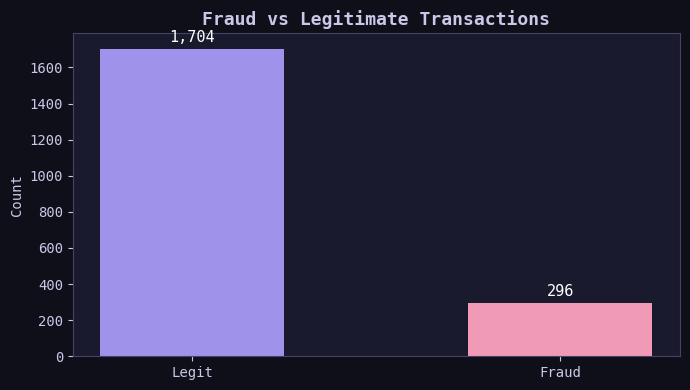

Saved → 01_fraud_distribution.png


In [20]:
fig, ax = plt.subplots(figsize=(7,4))
counts = df['IS_FRAUD'].value_counts()
bars = ax.bar(['Legit','Fraud'], counts.values, color=[PALETTE[0], PALETTE[1]], width=0.5, edgecolor='none')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{val:,}', ha='center', va='bottom', fontsize=11, color='white')
ax.set_title('Fraud vs Legitimate Transactions')
ax.set_ylabel('Count')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/01_fraud_distribution.png', dpi=150)
plt.show()
print("Saved → 01_fraud_distribution.png")


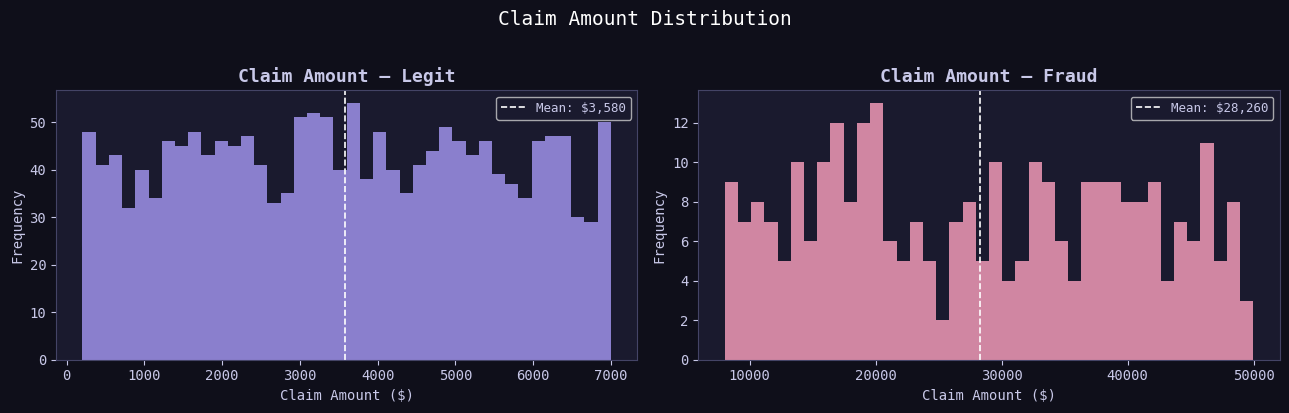

Saved → 02_claim_amount_dist.png


In [21]:

# Chart 2 — Claim amount distribution by fraud label
fig, axes = plt.subplots(1,2, figsize=(13,4))
for i, (label, title, color) in enumerate([(0,'Legit',PALETTE[0]),(1,'Fraud',PALETTE[1])]):
    sub = df[df['IS_FRAUD']==label]['CLAIM_AMOUNT']
    axes[i].hist(sub, bins=40, color=color, edgecolor='none', alpha=0.85)
    axes[i].set_title(f'Claim Amount — {title}')
    axes[i].set_xlabel('Claim Amount ($)')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(sub.mean(), color='white', linestyle='--', linewidth=1.2, label=f'Mean: ${sub.mean():,.0f}')
    axes[i].legend(fontsize=9)
plt.suptitle('Claim Amount Distribution', y=1.02, fontsize=14, color='white')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/02_claim_amount_dist.png', dpi=150)
plt.show()
print("Saved → 02_claim_amount_dist.png")


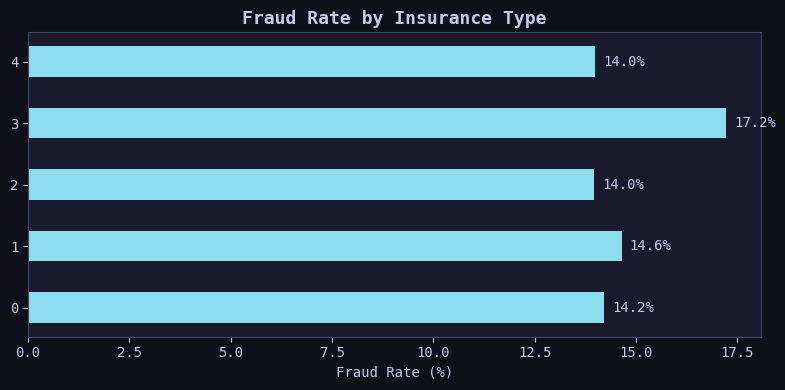

Saved → 03_fraud_by_insurance_type.png


In [22]:

# Chart 3 — Fraud rate by Insurance Type
fraud_by_type = (df.groupby('INSURANCE_TYPE')['IS_FRAUD']
                   .agg(['mean','count'])
                   .reset_index())
fraud_by_type.columns = ['INS_TYPE','FRAUD_RATE','COUNT']
fraud_by_type = fraud_by_type.sort_values('FRAUD_RATE', ascending=True)

fig, ax = plt.subplots(figsize=(8,4))
bars = ax.barh(fraud_by_type['INS_TYPE'], fraud_by_type['FRAUD_RATE']*100,
               color=PALETTE[2], edgecolor='none', height=0.5)
for bar, val in zip(bars, fraud_by_type['FRAUD_RATE']):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=10)
ax.set_title('Fraud Rate by Insurance Type')
ax.set_xlabel('Fraud Rate (%)')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/03_fraud_by_insurance_type.png', dpi=150)
plt.show()
print("Saved → 03_fraud_by_insurance_type.png")


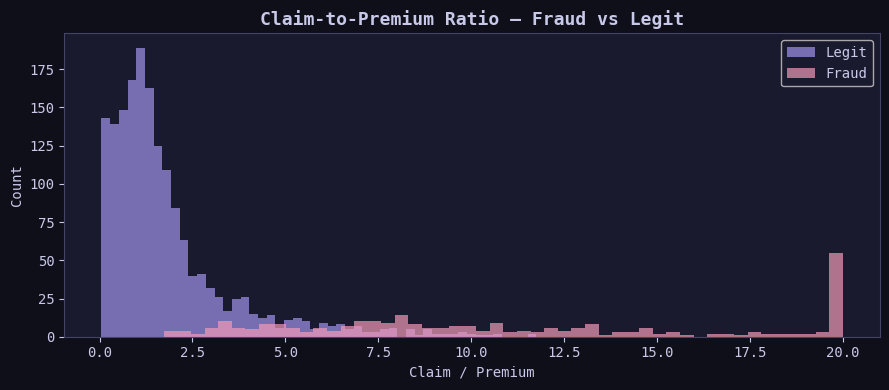

Saved → 04_claim_premium_ratio.png


In [23]:

# Chart 4 — Claim-to-Premium ratio (fraud vs legit)
fig, ax = plt.subplots(figsize=(9,4))
for label, color, lbl in [(0,PALETTE[0],'Legit'),(1,PALETTE[1],'Fraud')]:
    sub = df[df['IS_FRAUD']==label]['CLAIM_TO_PREMIUM_RATIO'].clip(0,20)
    ax.hist(sub, bins=50, alpha=0.7, color=color, label=lbl, edgecolor='none')
ax.set_title('Claim-to-Premium Ratio — Fraud vs Legit')
ax.set_xlabel('Claim / Premium')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT}/04_claim_premium_ratio.png', dpi=150)
plt.show()
print("Saved → 04_claim_premium_ratio.png")


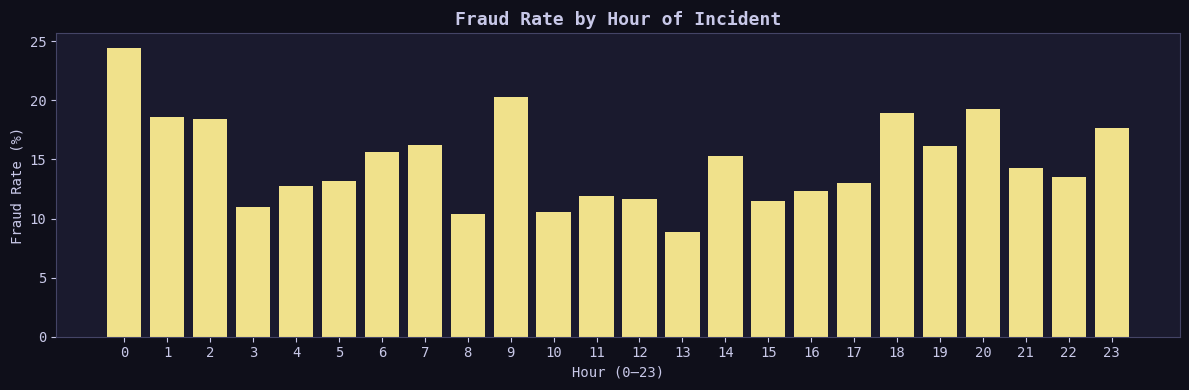

Saved → 05_fraud_by_hour.png


In [24]:

# Chart 5 — Fraud by hour of day
fraud_hour = (df.groupby('INCIDENT_HOUR_OF_THE_DAY')['IS_FRAUD']
                .mean().reset_index())
fig, ax = plt.subplots(figsize=(12,4))
ax.bar(fraud_hour['INCIDENT_HOUR_OF_THE_DAY'], fraud_hour['IS_FRAUD']*100,
       color=PALETTE[3], edgecolor='none', width=0.8)
ax.set_title('Fraud Rate by Hour of Incident')
ax.set_xlabel('Hour (0–23)')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xticks(range(0,24))
plt.tight_layout()
plt.savefig(f'{OUTPUT}/05_fraud_by_hour.png', dpi=150)
plt.show()
print("Saved → 05_fraud_by_hour.png")


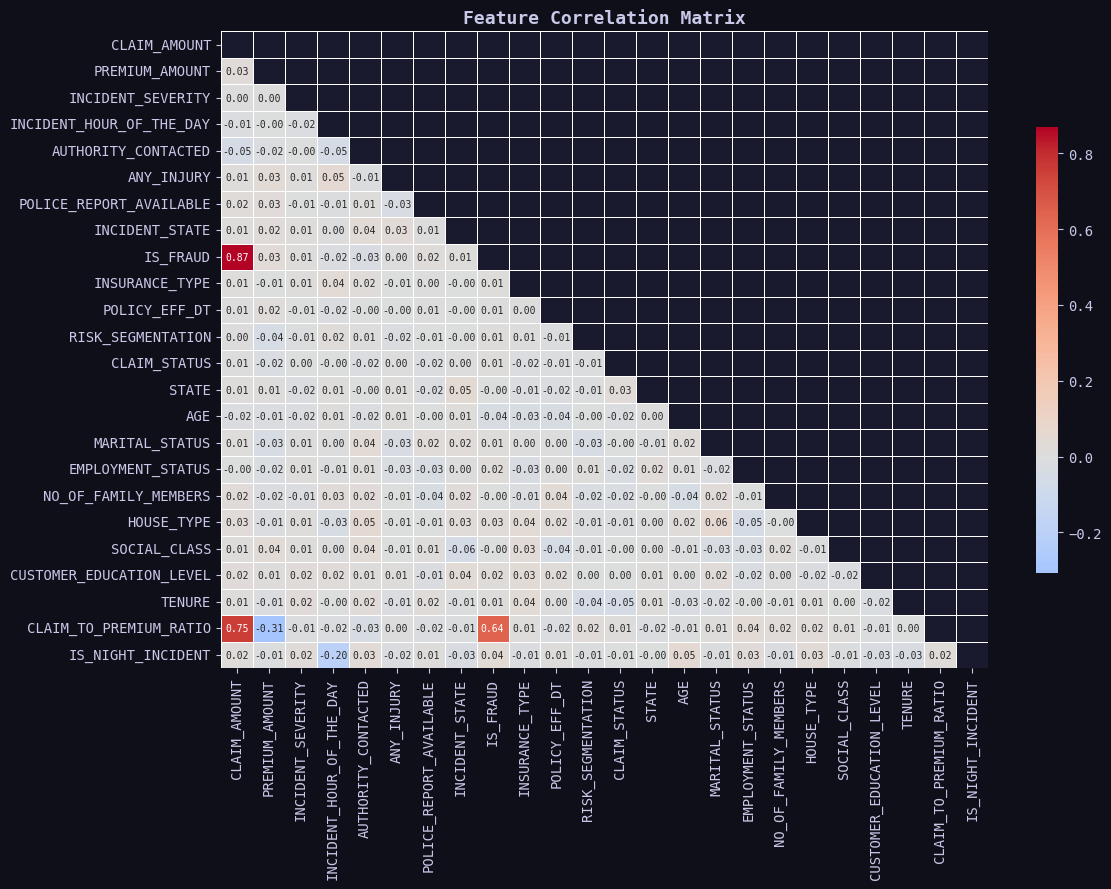

Saved → 06_correlation_heatmap.png


In [25]:

# Chart 6 — Correlation heatmap (numeric cols)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(12,9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax,
            cmap='coolwarm', center=0, annot=True, fmt='.2f',
            linewidths=0.4, annot_kws={'size':7},
            cbar_kws={'shrink':0.7})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/06_correlation_heatmap.png', dpi=150)
plt.show()
print("Saved → 06_correlation_heatmap.png")


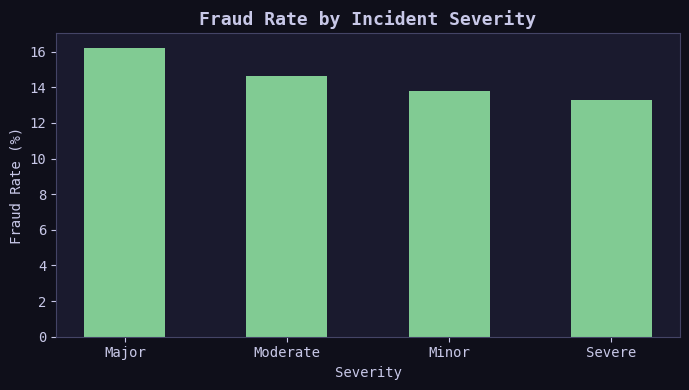

Saved → 07_fraud_by_severity.png


In [26]:

# Chart 7 — Fraud by Incident Severity
# Severity was label-encoded; decode roughly for display
sev_map = {0:'Minor',1:'Moderate',2:'Major',3:'Severe'}
df['SEV_LABEL'] = df['INCIDENT_SEVERITY'].map(sev_map).fillna('Other')
sev_fraud = df.groupby('SEV_LABEL')['IS_FRAUD'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(sev_fraud.index, sev_fraud.values*100,
       color=PALETTE[4], edgecolor='none', width=0.5)
ax.set_title('Fraud Rate by Incident Severity')
ax.set_xlabel('Severity')
ax.set_ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/07_fraud_by_severity.png', dpi=150)
plt.show()
df.drop(columns=['SEV_LABEL'], inplace=True)
print("Saved → 07_fraud_by_severity.png")


In [27]:

X = df.drop(columns=['IS_FRAUD'])
y = df['IS_FRAUD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Fraud in train: {y_train.mean():.2%}  |  Fraud in test: {y_test.mean():.2%}")


Train: (1600, 23)  |  Test: (400, 23)
Fraud in train: 14.81%  |  Fraud in test: 14.75%


In [28]:

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=13,
    min_samples_leaf=5,
    class_weight='balanced',   # handles class imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("Model trained")

# Cross-val AUC
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
print(f"5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Model trained
5-Fold CV AUC: 1.0000 ± 0.0000


In [29]:

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

print("="*55)
print("CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_test, y_pred, target_names=['Legit','Fraud']))
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       341
       Fraud       1.00      1.00      1.00        59

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

ROC-AUC  : 1.0000


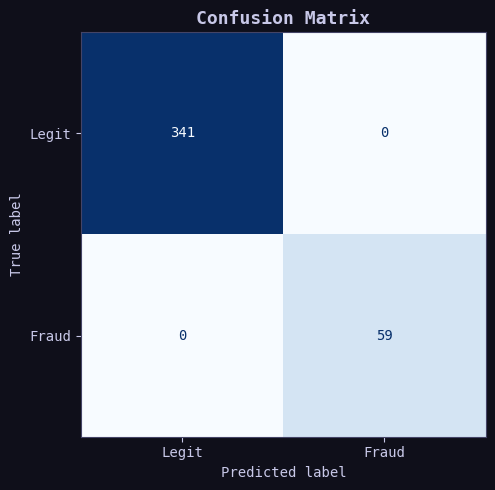

Saved → 08_confusion_matrix.png


In [30]:

# Chart 8 — Confusion Matrix
fig, ax = plt.subplots(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit','Fraud'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix')
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/08_confusion_matrix.png', dpi=150)
plt.show()
print("Saved → 08_confusion_matrix.png")


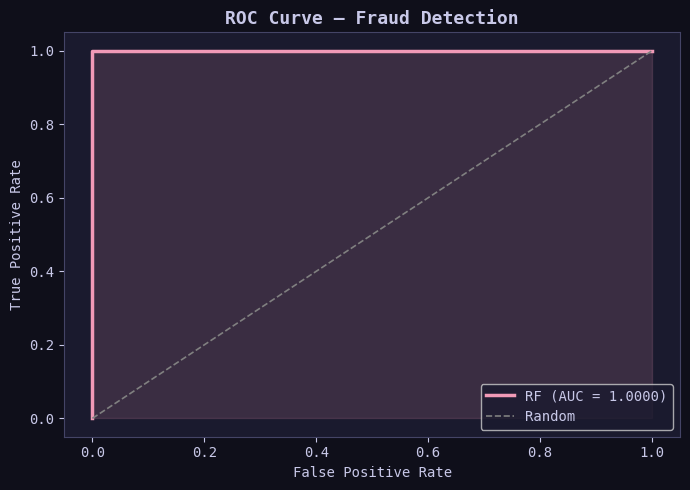

Saved → 09_roc_curve.png


In [31]:

# Chart 9 — ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(fpr, tpr, color=PALETTE[1], lw=2.5, label=f'RF (AUC = {auc_score:.4f})')
ax.plot([0,1],[0,1], color='grey', linestyle='--', lw=1.2, label='Random')
ax.fill_between(fpr, tpr, alpha=0.15, color=PALETTE[1])
ax.set_title('ROC Curve — Fraud Detection')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/09_roc_curve.png', dpi=150)
plt.show()
print("Saved → 09_roc_curve.png")


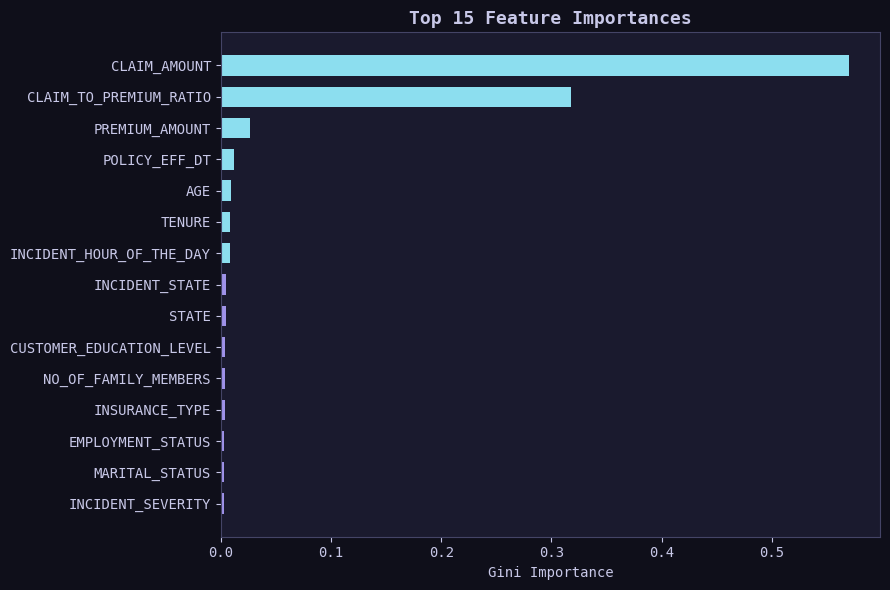

Saved → 10_feature_importances.png


In [32]:

# Chart 10 — Feature Importances (top 15)
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9,6))
colors = [PALETTE[2] if v > feat_imp.median() else PALETTE[0] for v in feat_imp.values]
ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='none', height=0.65)
ax.set_title('Top 15 Feature Importances')
ax.set_xlabel('Gini Importance')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/10_feature_importances.png', dpi=150)
plt.show()
print("Saved → 10_feature_importances.png")


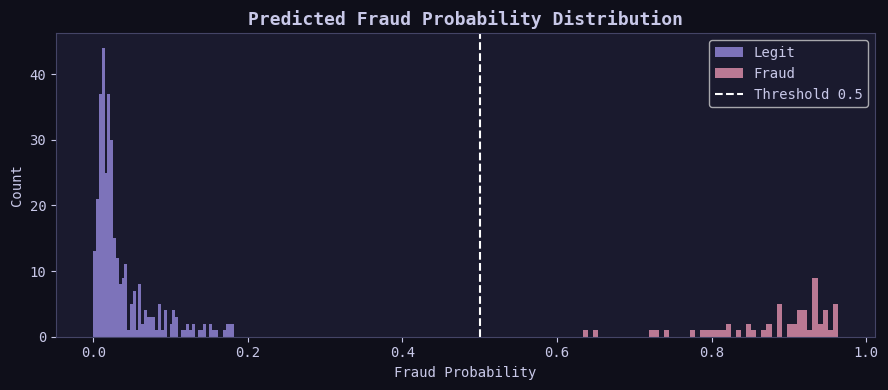

Saved → 11_probability_distribution.png


In [33]:

# Chart 11 — Predicted fraud probability distribution
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(y_proba[y_test==0], bins=50, alpha=0.75, color=PALETTE[0], label='Legit', edgecolor='none')
ax.hist(y_proba[y_test==1], bins=50, alpha=0.75, color=PALETTE[1], label='Fraud', edgecolor='none')
ax.axvline(0.5, color='white', linestyle='--', linewidth=1.5, label='Threshold 0.5')
ax.set_title('Predicted Fraud Probability Distribution')
ax.set_xlabel('Fraud Probability')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT}/11_probability_distribution.png', dpi=150)
plt.show()
print("Saved → 11_probability_distribution.png")


In [34]:

# Apply model on the full dataset to get risk scores
full_proba = rf.predict_proba(X)[:,1]

def risk_label(p):
    if p < 0.30: return 'Low'
    if p < 0.60: return 'Medium'
    if p < 0.80: return 'High'
    return 'Critical'

results = claims_history[['TRANSACTION_ID','POLICY_NUMBER','CUSTOMER_ID',
                           'CLAIM_AMOUNT','VENDOR_ID','IS_FRAUD']].copy()
results['FRAUD_PROBABILITY'] = full_proba.round(4)
results['RISK_SCORE']        = (full_proba * 100).round(2)   # 0–100
results['RISK_LABEL']        = results['FRAUD_PROBABILITY'].apply(risk_label)

print(results['RISK_LABEL'].value_counts())
results.head(10)


RISK_LABEL
Low         1704
Critical     286
High          10
Name: count, dtype: int64


,TRANSACTION_ID,POLICY_NUMBER,CUSTOMER_ID,CLAIM_AMOUNT,VENDOR_ID,IS_FRAUD,FRAUD_PROBABILITY,RISK_SCORE,RISK_LABEL
0,TXN0000001,POL000001,CUST00001,4591,VND0010,0,0.0299,2.99,Low
1,TXN0000002,POL000002,CUST00002,5069,VND0039,0,0.0405,4.05,Low
2,TXN0000003,POL000003,CUST00003,2019,VND0017,0,0.0531,5.31,Low
3,TXN0000004,POL000004,CUST00004,2628,VND0027,0,0.0235,2.35,Low
4,TXN0000005,POL000005,CUST00005,27629,VND0046,1,0.9603,96.03,Critical
5,TXN0000006,POL000006,CUST00006,5992,VND0010,0,0.0045,0.45,Low
6,TXN0000007,POL000007,CUST00007,3008,VND0022,0,0.0079,0.79,Low
7,TXN0000008,POL000008,CUST00008,1838,VND0009,0,0.0211,2.11,Low
8,TXN0000009,POL000009,CUST00009,10932,VND0022,1,0.9038,90.38,Critical
9,TXN0000010,POL000010,CUST00010,3861,VND0016,0,0.0358,3.58,Low


In [35]:

# Vendor risk aggregation — flag vendors linked to high-risk fraud claims
vendor_risk = (results[results['IS_FRAUD']==1]
               .groupby('VENDOR_ID')
               .agg(FRAUD_CLAIMS=('IS_FRAUD','sum'),
                    AVG_RISK_SCORE=('RISK_SCORE','mean'),
                    TOTAL_CLAIM_AMT=('CLAIM_AMOUNT','sum'))
               .sort_values('FRAUD_CLAIMS', ascending=False)
               .reset_index())

print("=== Top 10 High-Risk Vendors ===")
print(vendor_risk.head(10).to_string(index=False))
vendor_risk.to_csv(f'{OUTPUT}/vendor_risk_flags.csv', index=False)
print("Saved → vendor_risk_flags.csv")


=== Top 10 High-Risk Vendors ===
VENDOR_ID  FRAUD_CLAIMS  AVG_RISK_SCORE  TOTAL_CLAIM_AMT
  VND0027            13       90.644615           306560
  VND0016            12       93.854167           369733
  VND0042            11       93.710000           360961
  VND0050             9       92.083333           245975
  VND0029             9       92.193333           242592
  VND0037             8       93.211250           251273
  VND0013             8       92.275000           191950
  VND0008             8       93.842500           215954
  VND0014             8       91.276250           214634
  VND0005             8       93.147500           256338
Saved → vendor_risk_flags.csv


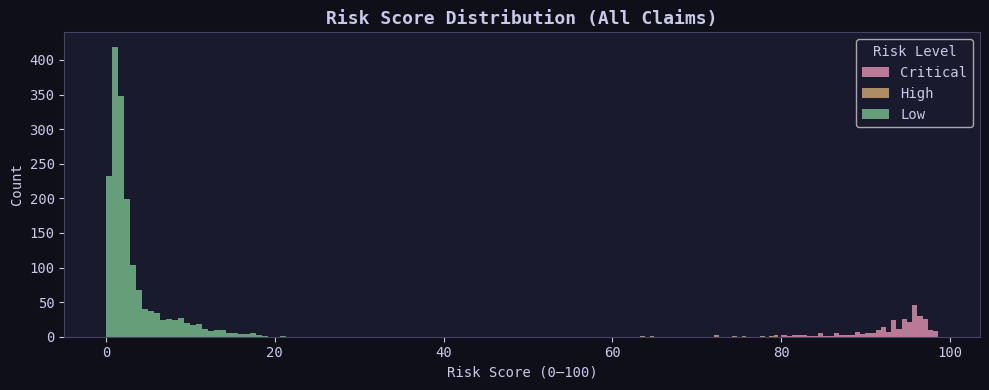

Saved → 12_risk_score_distribution.png


In [36]:

# Chart 12 — Risk score distribution across all claims
fig, ax = plt.subplots(figsize=(10,4))
colors_map = {'Low':PALETTE[4],'Medium':PALETTE[3],'High':PALETTE[5],'Critical':PALETTE[1]}
for lbl, grp in results.groupby('RISK_LABEL'):
    ax.hist(grp['RISK_SCORE'], bins=30, alpha=0.75,
            color=colors_map.get(lbl, PALETTE[0]), label=lbl, edgecolor='none')
ax.set_title('Risk Score Distribution (All Claims)')
ax.set_xlabel('Risk Score (0–100)')
ax.set_ylabel('Count')
ax.legend(title='Risk Level')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/12_risk_score_distribution.png', dpi=150)
plt.show()
print("Saved → 12_risk_score_distribution.png")


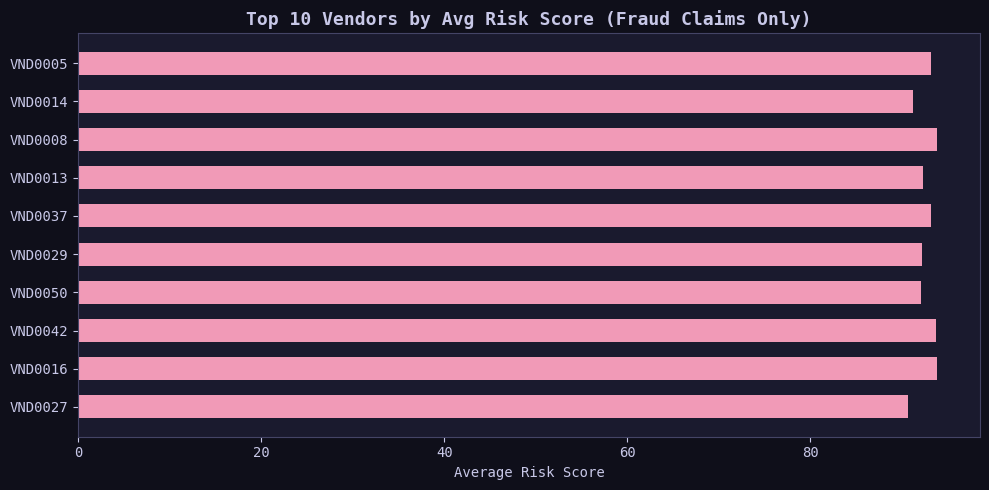

Saved → 13_top_risky_vendors.png


In [37]:

# Chart 13 — Top 10 Risky Vendors (bar)
top_vendors = vendor_risk.head(10)
fig, ax = plt.subplots(figsize=(10,5))
ax.barh(top_vendors['VENDOR_ID'], top_vendors['AVG_RISK_SCORE'],
        color=PALETTE[1], edgecolor='none', height=0.6)
ax.set_title('Top 10 Vendors by Avg Risk Score (Fraud Claims Only)')
ax.set_xlabel('Average Risk Score')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/13_top_risky_vendors.png', dpi=150)
plt.show()
print("Saved → 13_top_risky_vendors.png")


In [39]:

# Save final scored dataset
results.to_csv(f'{OUTPUT}/scored_claims.csv', index=False)
print("\nAll outputs saved to /output/")
print(f"   Charts  : 01–13 PNG files")
print(f"   Data    : scored_claims.csv, vendor_risk_flags.csv")
print(f"\nModel Summary:")
print(f"   Algorithm  : Random Forest (200 trees, balanced class weights)")
print(f"   ROC-AUC    : {roc_auc_score(y_test, y_proba):.4f}")
from sklearn.metrics import accuracy_score, f1_score
print(f"   Accuracy   : {accuracy_score(y_test, y_pred):.4f}")
print(f"   F1 (Fraud) : {f1_score(y_test, y_pred):.4f}")



All outputs saved to /output/
   Charts  : 01–13 PNG files
   Data    : scored_claims.csv, vendor_risk_flags.csv

Model Summary:
   Algorithm  : Random Forest (200 trees, balanced class weights)
   ROC-AUC    : 1.0000
   Accuracy   : 1.0000
   F1 (Fraud) : 1.0000
